In [219]:
import numpy as np
import globals as gl
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib.lines import Line2D
import pickle
import seaborn as sb
import PcmPy as pcm

plt.style.use('default')

In [220]:
experiment = 'smp3'
sn = 100

In [221]:
pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
blocks = pinfo[pinfo.sn == sn].reset_index().blocks_emg_task[0].split(',')
channels_emg = pinfo[pinfo.sn == sn].reset_index().channels_emg[0].split(',')
dat = pd.read_csv(os.path.join(gl.baseDir, experiment, 'behavioural', f'subj{sn}',f'{experiment}_{sn}.dat'), sep='\t')
tgt = pd.DataFrame()
for block in blocks:
    tgt_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, 'target', f'{experiment}_{sn}_{int(block):02d}.tgt'), sep='\t')
    tgt = pd.concat([tgt, tgt_tmp], ignore_index=True)
dat  = pd.concat([dat, tgt[['TrigPlan', 'TrigExec', 'TrigBaseline']]], axis=1)
dat.cue = dat.cue.map(gl.cue_mapping)
dat.stimFinger = dat.stimFinger.map(gl.stimFinger_mapping)
dat_tms = dat[(dat['TrigPlan']==1) | (dat['TrigExec']==1) | (dat['TrigBaseline']==1)]
dat_tms = dat_tms.reset_index(drop=True)
new_rows = []
for i, row in dat_tms.iterrows():
    new_rows.append(row)  # Append the actual row
    if row['TrigBaseline'] == 1:
        new_rows.append(pd.Series(dtype=object))  # Append empty row
dat_tms = pd.DataFrame(new_rows).reset_index(drop=True)

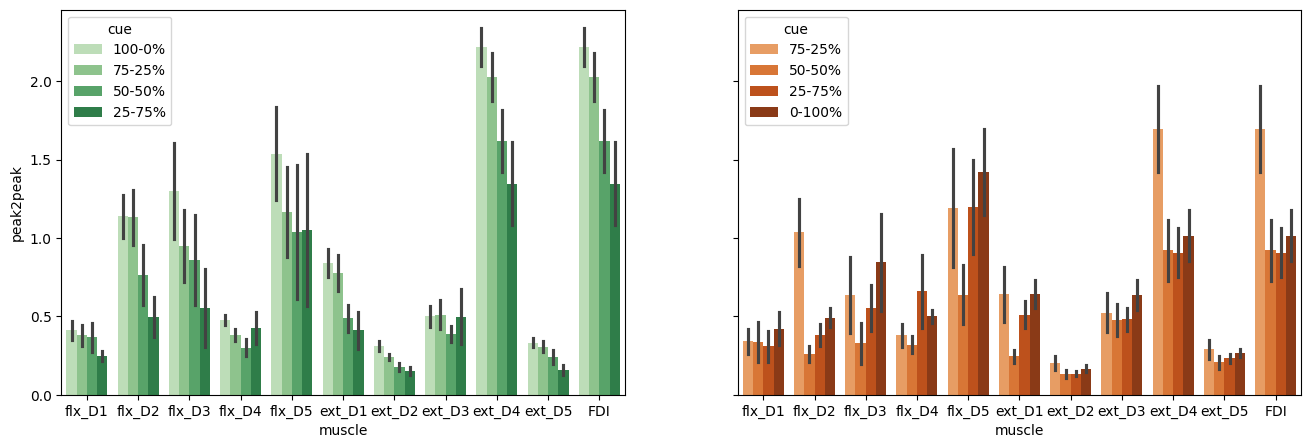

In [222]:
mep = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'emg_raw.tms.task.npy'))
# mep_rect = np.abs(mep)
mep_exec = mep[(dat_tms['TrigExec'] == 1)]
dat_tms_exec = dat_tms[(dat_tms['TrigExec'] == 1)].reset_index()
tAx = np.linspace(-1, 2, mep.shape[-1])
int_mep = np.where((tAx > .015) & (tAx < .075))[0]
int_bs = np.where((tAx > -.1) & (tAx < .0))
# bs = mep_exec[..., int_bs].mean(axis=-1, )
# mep_rect_exec_bs = mep_rect_exec - bs
p2p = np.ptp(mep_exec[..., int_mep], axis=-1)
df_p2p = pd.DataFrame(p2p, columns=channels_emg)
df_p2p = pd.concat([dat_tms_exec[['stimFinger', 'cue', 'BN']], df_p2p], axis=1, )
df_p2p_melt = pd.melt(df_p2p, value_vars=channels_emg, id_vars=['stimFinger', 'cue', 'BN'], value_name='peak2peak', var_name='muscle')

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(16, 5))

sb.barplot(data=df_p2p_melt[df_p2p_melt['stimFinger']=='index'], ax=axs[0], y='peak2peak', x='muscle', hue='cue', palette=list(gl.colour_mapping.values())[5:9], hue_order=list(gl.colour_mapping.keys())[:4], errorbar='se')
sb.barplot(data=df_p2p_melt[df_p2p_melt['stimFinger']=='ring'], ax=axs[1], y='peak2peak', x='muscle', hue='cue', palette=list(gl.colour_mapping.values())[9:13],hue_order=list(gl.colour_mapping.keys())[1:5], errorbar='se')

plt.show()

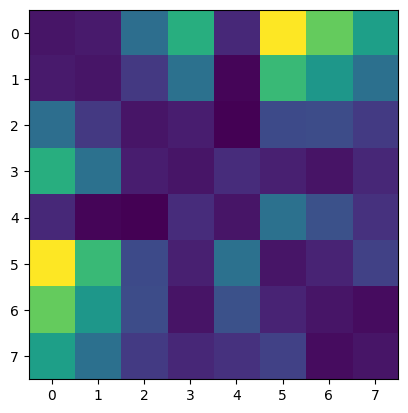

In [223]:
df_p2p_avg_run = df_p2p.groupby(['stimFinger', 'cue', 'BN']).mean(numeric_only=True).reset_index()
meas = df_p2p_avg_run[channels_emg].to_numpy()

# prewhitening
meas = meas.reshape(8, 9, 11)
df_p2p_avg = df_p2p.groupby(['stimFinger', 'cue']).mean(numeric_only=True).reset_index()
meas_avg = df_p2p_avg[channels_emg].to_numpy()
res = meas - meas_avg[:, None, :]
res = res.reshape(72, 11).T
cov = res @ res.T
meas = meas.reshape(72, 11) / np.sqrt(np.diag(cov))

cond_vec = df_p2p_avg_run['cue'] + ',' + df_p2p_avg_run['stimFinger']
cond_vec = cond_vec.map(gl.regressor_mapping)
obs_des = {'cond_vec': cond_vec,
           'part_vec': df_p2p_avg_run['BN']}

Y = pcm.dataset.Dataset(meas, obs_descriptors=obs_des)

G, _ = pcm.est_G_crossval(Y.measurements,
                       Y.obs_descriptors['cond_vec'],
                       Y.obs_descriptors['part_vec'],
                       X=pcm.indicator(Y.obs_descriptors['part_vec']),)
D = pcm.G_to_dist(G)

plt.imshow(D)

plt.show()

In [224]:
f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.exec.p'), "rb")
M = pickle.load(f)
T_in, theta_in = pcm.fit_model_individ(Y, M, fit_scale=False, verbose=True, fixed_effect='block')

# variance explained
params_c = theta_in[5]
theta_c = params_c[:M[5].n_param]
var_expl = np.exp(theta_c)

# interaction
params_f = theta_in[6]
theta_f = params_f[:M[6].n_param]
interaction = theta_f[1, :] * theta_f[2, :]

print(f'interaction={interaction}')

Fitting Subj 0 model 0
Fitting Subj 0 model 1
Fitting Subj 0 model 2
Fitting Subj 0 model 3
Fitting Subj 0 model 4
Fitting Subj 0 model 5
Fitting Subj 0 model 6
Fitting Subj 0 model 7
interaction=[0.004092]


In [225]:
# interaction = np.zeros(len(int_mep))
# for I, i in enumerate(int_mep):
#     y = mep_rect_exec[..., i]
#     df = pd.DataFrame(y, columns=channels_emg)
#     df = pd.concat([dat_tms_exec[['stimFinger', 'cue', 'BN']], df], axis=1)
#     df = df.groupby(['stimFinger', 'cue', 'BN']).mean(numeric_only=True).reset_index()
#     meas = df[channels_emg].to_numpy()
#     Y = pcm.dataset.Dataset(meas, obs_descriptors=obs_des)
#     T_in, theta_in = pcm.fit_model_individ(Y, M, fit_scale=False, verbose=False, fixed_effect='block')
#     params_f = theta_in[6]
#     theta_f = params_f[:M[6].n_param]
#     interaction[I] = theta_f[1, :] * theta_f[2, :]

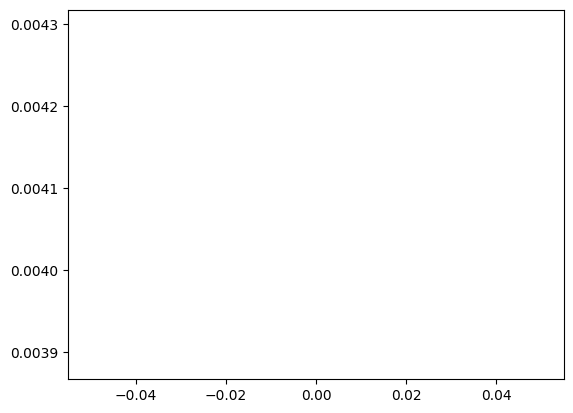

In [226]:
plt.plot(interaction)